<a href="https://colab.research.google.com/github/PoojaKumariR-student/Dynamic-Pricing-E-Commerce-using-Google-Colab-/blob/main/Dynamic_Pricing_E_commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Step 1 - Loading the Libraries:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier

# **Step 2 - Loading the Dataset**

In [ ]:
df = pd.read_csv("/content/ecommerce_sales_analysis.csv")
df

,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12,Unnamed: 18
0,1,Product_1,Clothing,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306,NaN
1,2,Product_2,Home & Kitchen,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353,NaN
2,3,Product_3,Toys,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392,NaN
3,4,Product_4,Toys,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203,NaN
4,5,Product_5,Books,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Product_996,Home & Kitchen,50.33,3.6,494,488,359,137,787,678,970,282,155,57,575,634,393,NaN
996,997,Product_997,Home & Kitchen,459.07,4.8,701,18,906,129,78,19,110,403,683,104,858,729,474,NaN
997,998,Product_998,Sports,72.73,1.3,287,725,109,193,657,215,337,664,476,265,344,888,654,NaN
998,999,Product_999,Sports,475.37,1.2,720,196,191,315,622,854,122,65,938,521,268,60,394,NaN


# **Step 3 - Undersatanding the Dataset**

In [ ]:
df.head()

,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12,Unnamed: 18
0,1,Product_1,Clothing,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306,NaN
1,2,Product_2,Home & Kitchen,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353,NaN
2,3,Product_3,Toys,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392,NaN
3,4,Product_4,Toys,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203,NaN
4,5,Product_5,Books,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257,NaN


In [ ]:
df.tail()

,product_id,product_name,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12,Unnamed: 18
995,996,Product_996,Home & Kitchen,50.33,3.6,494,488,359,137,787,678,970,282,155,57,575,634,393,NaN
996,997,Product_997,Home & Kitchen,459.07,4.8,701,18,906,129,78,19,110,403,683,104,858,729,474,NaN
997,998,Product_998,Sports,72.73,1.3,287,725,109,193,657,215,337,664,476,265,344,888,654,NaN
998,999,Product_999,Sports,475.37,1.2,720,196,191,315,622,854,122,65,938,521,268,60,394,NaN
999,1000,Product_1000,Toys,225.77,2.1,114,890,903,983,769,134,704,648,400,495,839,611,110,NaN


In [ ]:
df.shape

(1000, 19)

In [ ]:
df.info

<bound method DataFrame.info of      product_id  product_name        category   price  review_score  \
0             1     Product_1        Clothing  190.40           1.7   
1             2     Product_2  Home & Kitchen  475.60           3.2   
2             3     Product_3            Toys  367.34           4.5   
3             4     Product_4            Toys  301.34           3.9   
4             5     Product_5           Books   82.23           4.2   
..          ...           ...             ...     ...           ...   
995         996   Product_996  Home & Kitchen   50.33           3.6   
996         997   Product_997  Home & Kitchen  459.07           4.8   
997         998   Product_998          Sports   72.73           1.3   
998         999   Product_999          Sports  475.37           1.2   
999        1000  Product_1000            Toys  225.77           2.1   

     review_count  sales_month_1  sales_month_2  sales_month_3  sales_month_4  \
0             220            479            449             92            784   
1             903             21            989            861            863   
2             163            348            558            567            143   
3             951            725            678             59             15   
4             220            682            451            649            301   
..            ...            ...            ...            ...            ...   
995           494            488            359            137            787   
996           701             18            906            129             78   
997           287            725            109            193            657   
998           720            196            191            315            622   
999           114            890            903            983            769   

     sales_month_5  sales_month_6  sales_month_7  sales_month_8  \
0              604            904            446            603   
1              524            128            610            436   
2              771            409            290            828   
3              937            421            670            933   
4              620            293            411            258   
..             ...            ...            ...            ...   
995            678            970            282            155   
996             19            110            403            683   
997            215            337            664            476   
998            854            122             65            938   
999            134            704            648            400   

     sales_month_9  sales_month_10  sales_month_11  sales_month_12  \
0              807             252             695             306   
1              176             294             772             353   
2              340             667             267             392   
3               56             157             168             203   
4              854             548             770             257   
..             ...             ...             ...             ...   
995             57             575             634             393   
996            104             858             729             474   
997            265             344             888             654   
998            521             268              60             394   
999            495             839             611             110   

     Unnamed: 18  
0            NaN  
1            NaN  
2            NaN  
3            NaN  
4            NaN  
..           ...  
995          NaN  
996          NaN  
997          NaN  
998          NaN  
999          NaN  

[1000 rows x 19 columns]>

In [ ]:
df.describe()

,product_id,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12,Unnamed: 18
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,0.0
mean,500.500000,247.677130,3.027600,526.506000,498.306000,507.661000,506.739000,503.823000,487.194000,491.653000,507.011000,504.569000,491.934000,514.798000,505.83800,500.386000,NaN
std,288.819436,144.607983,1.171243,282.269932,289.941478,285.992689,294.010873,286.645567,287.844324,289.234018,291.047287,289.945691,287.514731,288.710119,288.82451,278.509459,NaN
min,1.000000,7.290000,1.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,1.000000,0.00000,4.000000,NaN
25%,250.750000,121.810000,2.000000,283.750000,245.500000,262.500000,243.750000,261.500000,221.000000,236.000000,254.000000,240.500000,247.250000,267.000000,251.25000,259.000000,NaN
50%,500.500000,250.920000,3.100000,543.000000,507.500000,508.000000,493.000000,501.500000,497.000000,479.500000,522.500000,499.500000,495.500000,532.000000,502.00000,500.500000,NaN
75%,750.250000,373.435000,4.000000,772.000000,740.750000,756.250000,777.250000,749.500000,727.000000,740.500000,757.250000,762.250000,735.250000,770.250000,761.00000,730.000000,NaN
max,1000.000000,499.860000,5.000000,999.000000,1000.000000,1000.000000,999.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,NaN


In [ ]:
df.columns

Index(['product_id', 'product_name', 'category', 'price', 'review_score',
       'review_count', 'sales_month_1', 'sales_month_2', 'sales_month_3',
       'sales_month_4', 'sales_month_5', 'sales_month_6', 'sales_month_7',
       'sales_month_8', 'sales_month_9', 'sales_month_10', 'sales_month_11',
       'sales_month_12', 'Unnamed: 18'],
      dtype='object')

# Step 4 - Cleaning the Data

In [ ]:
df.isnull().sum()

,0
product_id,0
product_name,0
category,0
price,0
review_score,0
review_count,0
sales_month_1,0
sales_month_2,0
sales_month_3,0
sales_month_4,0


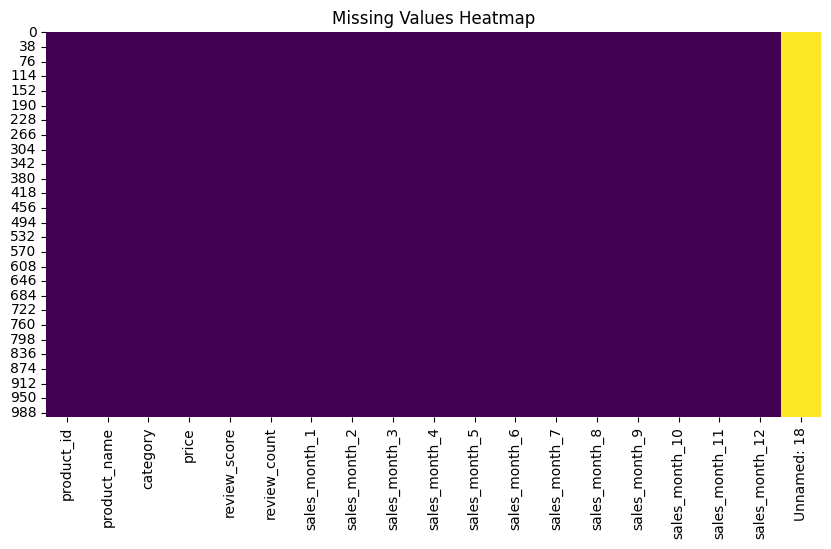

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [ ]:
df = df.drop(columns="Unnamed: 18")

In [ ]:
df = df.drop(columns="product_name")

In [ ]:
df.drop_duplicates()

,product_id,category,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12
0,1,Clothing,190.40,1.7,220,479,449,92,784,604,904,446,603,807,252,695,306
1,2,Home & Kitchen,475.60,3.2,903,21,989,861,863,524,128,610,436,176,294,772,353
2,3,Toys,367.34,4.5,163,348,558,567,143,771,409,290,828,340,667,267,392
3,4,Toys,301.34,3.9,951,725,678,59,15,937,421,670,933,56,157,168,203
4,5,Books,82.23,4.2,220,682,451,649,301,620,293,411,258,854,548,770,257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,Home & Kitchen,50.33,3.6,494,488,359,137,787,678,970,282,155,57,575,634,393
996,997,Home & Kitchen,459.07,4.8,701,18,906,129,78,19,110,403,683,104,858,729,474
997,998,Sports,72.73,1.3,287,725,109,193,657,215,337,664,476,265,344,888,654
998,999,Sports,475.37,1.2,720,196,191,315,622,854,122,65,938,521,268,60,394


In [ ]:
df.shape

(1000, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      1000 non-null   int64  
 1   category        1000 non-null   object 
 2   price           1000 non-null   float64
 3   review_score    1000 non-null   float64
 4   review_count    1000 non-null   int64  
 5   sales_month_1   1000 non-null   int64  
 6   sales_month_2   1000 non-null   int64  
 7   sales_month_3   1000 non-null   int64  
 8   sales_month_4   1000 non-null   int64  
 9   sales_month_5   1000 non-null   int64  
 10  sales_month_6   1000 non-null   int64  
 11  sales_month_7   1000 non-null   int64  
 12  sales_month_8   1000 non-null   int64  
 13  sales_month_9   1000 non-null   int64  
 14  sales_month_10  1000 non-null   int64  
 15  sales_month_11  1000 non-null   int64  
 16  sales_month_12  1000 non-null   int64  
dtypes: float64(2), int64(14), object(1

In [ ]:
df.describe()

,product_id,price,review_score,review_count,sales_month_1,sales_month_2,sales_month_3,sales_month_4,sales_month_5,sales_month_6,sales_month_7,sales_month_8,sales_month_9,sales_month_10,sales_month_11,sales_month_12
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,247.677130,3.027600,526.506000,498.306000,507.661000,506.739000,503.823000,487.194000,491.653000,507.011000,504.569000,491.934000,514.798000,505.83800,500.386000
std,288.819436,144.607983,1.171243,282.269932,289.941478,285.992689,294.010873,286.645567,287.844324,289.234018,291.047287,289.945691,287.514731,288.710119,288.82451,278.509459
min,1.000000,7.290000,1.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,1.000000,0.00000,4.000000
25%,250.750000,121.810000,2.000000,283.750000,245.500000,262.500000,243.750000,261.500000,221.000000,236.000000,254.000000,240.500000,247.250000,267.000000,251.25000,259.000000
50%,500.500000,250.920000,3.100000,543.000000,507.500000,508.000000,493.000000,501.500000,497.000000,479.500000,522.500000,499.500000,495.500000,532.000000,502.00000,500.500000
75%,750.250000,373.435000,4.000000,772.000000,740.750000,756.250000,777.250000,749.500000,727.000000,740.500000,757.250000,762.250000,735.250000,770.250000,761.00000,730.000000
max,1000.000000,499.860000,5.000000,999.000000,1000.000000,1000.000000,999.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000


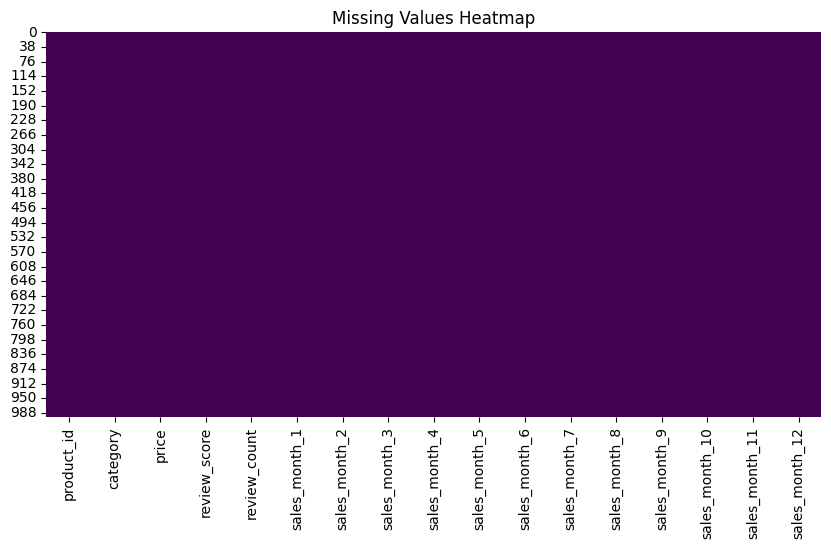

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

# **Step 5 - Data Visualization**

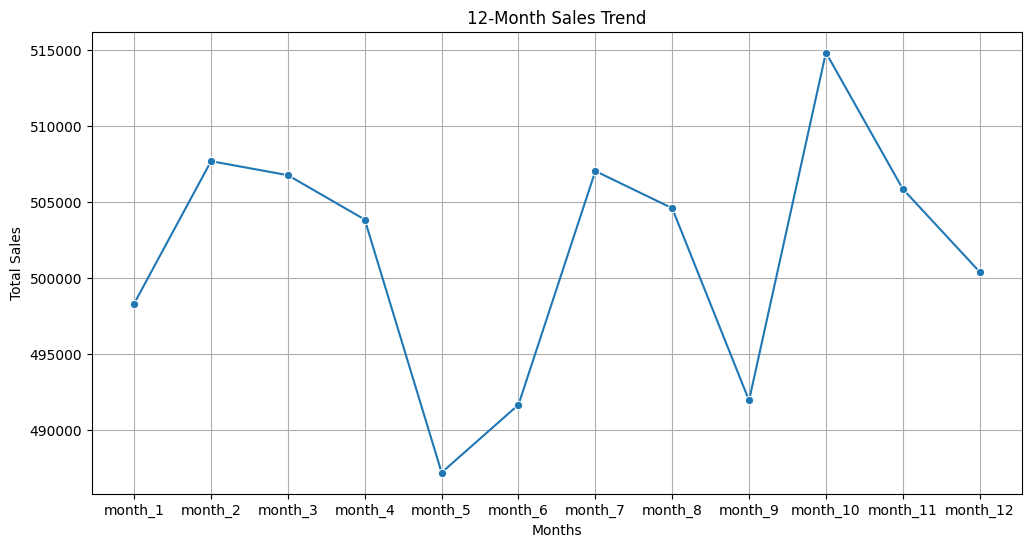

In [ ]:
monthly_sales = df[[
    'sales_month_1',
    'sales_month_2',
    'sales_month_3',
    'sales_month_4',
    'sales_month_5',
    'sales_month_6',
    'sales_month_7',
    'sales_month_8',
    'sales_month_9',
    'sales_month_10',
    'sales_month_11',
    'sales_month_12'
]]

# Calculate total sales for each month
monthly_totals = monthly_sales.sum()

# Create month labels
months = [
    'month_1', 'month_2', 'month_3', 'month_4',
    'month_5', 'month_6', 'month_7', 'month_8',
    'month_9', 'month_10', 'month_11', 'month_12'
]

# Plot graph
plt.figure(figsize=(12,6))
sns.lineplot(
    x=months,
    y=monthly_totals.values,
    marker='o'
)

plt.title('12-Month Sales Trend')
plt.xlabel('Months')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

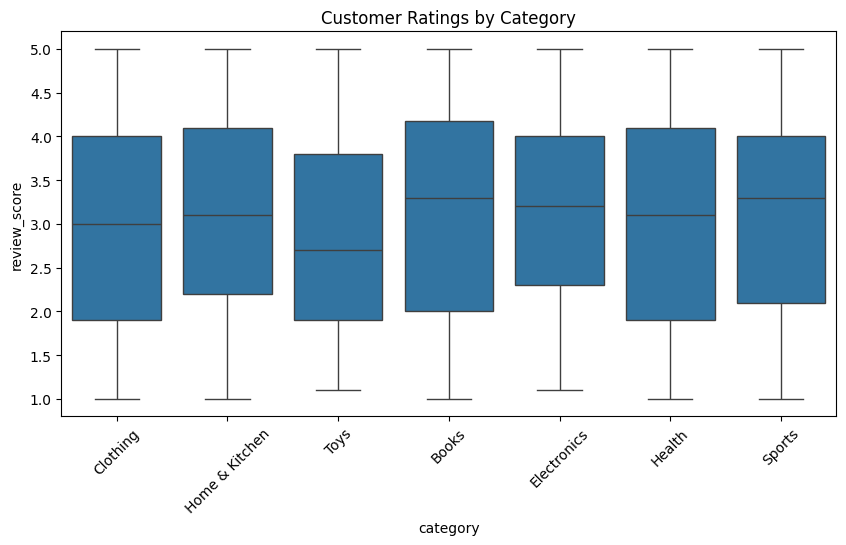

In [ ]:
if 'review_score' in df.columns:

    plt.figure(figsize=(10,5))
    sns.boxplot(
        x='category',
        y='review_score',
        data=df
    )

    plt.xticks(rotation=45)
    plt.title('Customer Ratings by Category')
    plt.show()

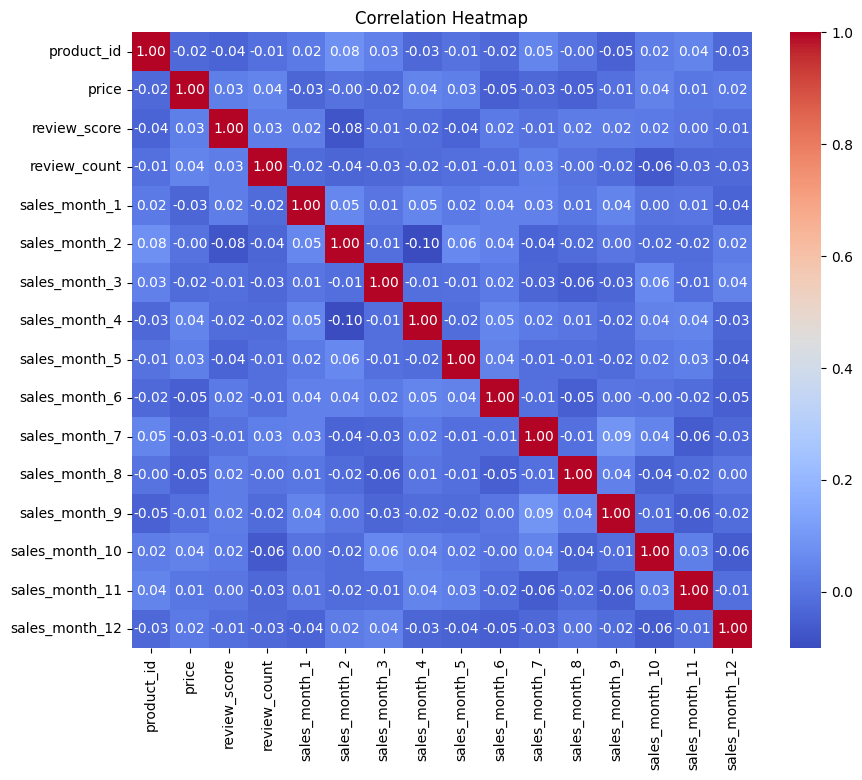

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

Target Column

In [ ]:
df['Total_Sales'] = (
    df['sales_month_1'] +
    df['sales_month_2'] +
    df['sales_month_3'] +
    df['sales_month_4'] +
    df['sales_month_5'] +
    df['sales_month_6'] +
    df['sales_month_7'] +
    df['sales_month_8'] +
    df['sales_month_9'] +
    df['sales_month_10'] +
    df['sales_month_11'] +
    df['sales_month_12']
)

In [ ]:
average_sales = df['Total_Sales'].mean()
print(average_sales)

6019.912


In [ ]:
df['Target'] = (
    df['Total_Sales'] > average_sales
).astype(int)

In [ ]:
print(df[['Total_Sales', 'Target']].head())

   Total_Sales  Target
0         6421       1
1         6027       1
2         5580       0
3         5022       0
4         6094       1


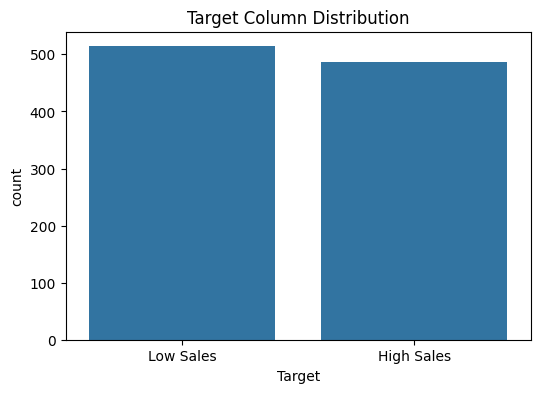

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Target',
    data=df
)

plt.xticks([0,1], ['Low Sales', 'High Sales'])

plt.title('Target Column Distribution')

plt.show()

In [ ]:
df["Target"].value_counts()

,count
Target,
0,514
1,486


# **Step 6 - Model Training and Evaluation**

In [ ]:
df.dtypes

,0
product_id,int64
category,object
price,float64
review_score,float64
review_count,int64
sales_month_1,int64
sales_month_2,int64
sales_month_3,int64
sales_month_4,int64
sales_month_5,int64


In [ ]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
df.dtypes

,0
product_id,int64
category,int64
price,float64
review_score,float64
review_count,int64
sales_month_1,int64
sales_month_2,int64
sales_month_3,int64
sales_month_4,int64
sales_month_5,int64


In [ ]:
scaler = StandardScaler()

numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

if 'Sales' in numeric_columns:
    numeric_columns = numeric_columns.drop('Sales')

df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

In [ ]:
median_sales = df['Target'].median()

# 1 = High Sales
# 0 = Low Sales

df['High_Sales'] = (df['Target'] > median_sales).astype(int)

In [ ]:
X = df.drop('High_Sales', axis=1)

y = df['High_Sales']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Random Forest Model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       107
           1       1.00      1.00      1.00        93

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
rf_accuracy = accuracy_score(y_test, rf_pred)
print('Random Forest Accuracy:', rf_accuracy)

Random Forest Accuracy: 1.0


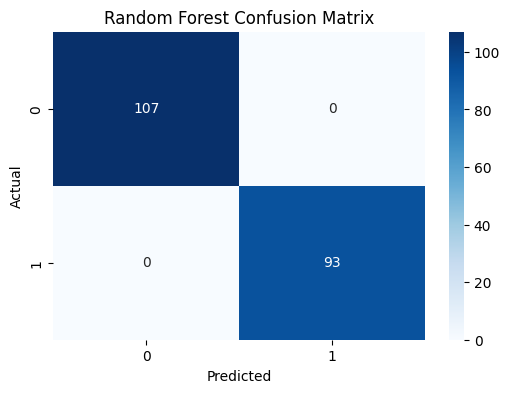

In [ ]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# XGBoost

In [ ]:
!pip install xgboost
!pip install shap
!pip install tensorflow

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb_model.predict(X_test)

In [ ]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       107
           1       1.00      1.00      1.00        93

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
print('XGBoost Accuracy:', xgb_accuracy)

XGBoost Accuracy: 1.0


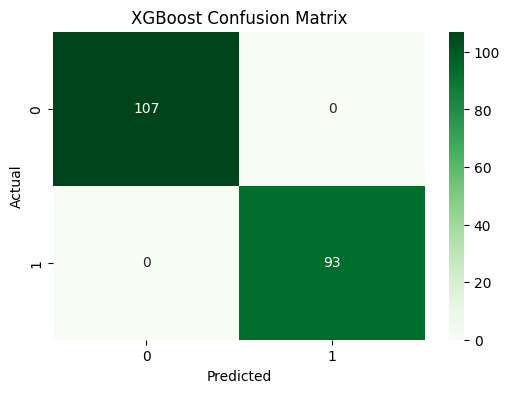

In [ ]:
xgb_cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Reinforcement Learning

In [ ]:
Q = np.zeros((5,5))
learning_rate = 0.8
gamma = 0.95
for i in range(100):

    state = np.random.randint(0,5)

    action = np.random.randint(0,5)

    reward = np.random.randint(1,10)

    Q[state, action] = Q[state, action] + learning_rate * (
        reward + gamma * np.max(Q[action,:]) - Q[state, action]
    )

print(Q)

[[38.21720366 47.23920816 39.97500401 18.83273065 40.24084692]
 [35.47460283 45.60932452 43.65987227 20.57352966 47.42761764]
 [29.70190229 46.62499216 46.50003552 22.10102665 48.80265934]
 [39.08435322 44.72906362 54.35946724 33.86248033 50.93911957]
 [32.67642123 28.77872785 19.09168606 45.91211173 44.58956664]]


In [ ]:
print('Random Forest Accuracy:', rf_accuracy)
print('XGBoost Accuracy:', xgb_accuracy)

Random Forest Accuracy: 1.0
XGBoost Accuracy: 1.0
